# Minimal Early Exit Neural Network
This is an extremely simple neural network that has exiting behavior controlled by a parameter lambda. 

I want to start with this simple case that I can code from the ground up to understand what's happening.

Also, this allows me to play with some toy examples of analysis I'll do later on.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load CIFAR10 data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
batch_size = 1
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92941177..0.92156863].


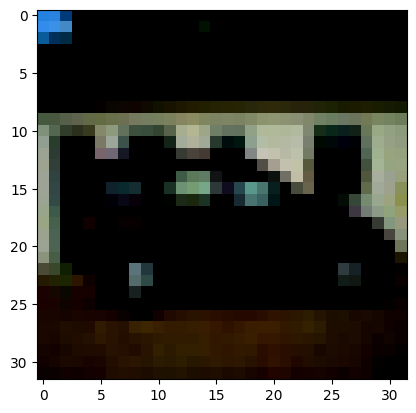

car  


In [3]:
# Define a function to display the images
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [4]:
images.shape

torch.Size([1, 3, 32, 32])

In [5]:
# Load a pretrained network (ResNet 50 architecture diagram: https://towardsdatascience.com/the-annotated-resnet-50-a6c536034758)
model = torch.hub.load("pytorch/vision", "resnet50", weights="IMAGENET1K_V2")
model.eval()
print('Loaded successfully.')

Using cache found in /Users/andreawynn/.cache/torch/hub/pytorch_vision_main


Loaded successfully.


In [6]:
# Look at the output shape of the final layer
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [7]:
# Run some sample images through the model
model(images).shape[1] # get the dimension of the feature vector after the final FC layer

1000

# Implementation 1: Static Early Exit
Always early exit after a specific layer.

In [9]:
# Dictionary to store intermediate outputs
intermediate_outputs = {}

# Get the intermediate outputs from each hidden layer using a hook
def get_intermediate_output(layer_name):
    def hook_fn(module, input, output):
        # Save the output
        intermediate_outputs[layer_name] = output
    return hook_fn

In [10]:
# Create a classifier into which we feed the feature vector from each early exit. 
# Note: need to compute softmax over these outputs later for lambda-thresholding
class Classifier(nn.Module):
    def __init__(self, input_dim):
        super(Classifier, self).__init__()
        # Define a simple feedforward network for classifying intermediate output
        self.fc = nn.Linear(input_dim, 10) 
        
    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)
        # Pass through the layers
        x = self.fc(x)
        return x

In [11]:
layer_names = ['maxpool', 'layer1', 'layer2', 'layer3', 'layer4', 'fc']

In [13]:
# Create all the hooks and classifiers and save them out. 
classifiers = {}
hooks = {}
for layer_name in layer_names:
    print(layer_name)
    layer = dict(model.named_modules())[layer_name]
    hooks[layer_name] = layer.register_forward_hook(get_intermediate_output(layer_name))
    with torch.no_grad():
        model(images)
    dims = intermediate_outputs[layer_name].view(batch_size, -1).shape[1]
    print(dims)
    classifiers[layer_name] = Classifier(dims)

maxpool
4096
layer1
16384
layer2
8192
layer3
4096
layer4
2048
fc
1000


In [14]:
# Define training iteration for classifier on a specific layer
def do_train(layer_name, cl, images, labels):
    # Forward pass through the model
    with torch.no_grad():
        model(images)
    
    criterion = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    # Forward pass
    output = cl(intermediate_outputs[layer_name])
    
    # Compute the loss
    loss = criterion(output, labels)
    
    # Backward pass and optimization
    optimizer.zero_grad()  # Zero the gradients
    loss.backward()        # Backpropagate the loss
    optimizer.step()       # Update the weights

In [20]:
# Big training loop. (Note: the ResNet model is frozen, we are only training classifiers!)
for epoch in range(10):
    print('Epoch', epoch+1)
    for i, data in enumerate(trainloader, 0):
        images, labels = data
        for layer_name in layer_names:
            do_train(layer_name, classifiers[layer_name], images, labels)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9


In [21]:
# Evaluate each early exit classifier on test data. Compute this over ALL layers!
correct = {}
total = 0
for layer_name in layer_names:
    correct[layer_name] = 0

# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        total += labels.size(0)
        model(images)
        
        for layer_name in layer_names:
            # calculate outputs by running images through the early exit classifier
            outputs = classifiers[layer_name](intermediate_outputs[layer_name])
            # the class with the highest probability is what we choose as prediction
            _, predicted = torch.max(outputs.data, dim=1)
            correct[layer_name] += (predicted == labels).sum().item()

# print accuracy for each layer
for layer_name in layer_names:
    print(layer_name, 'accuracy (out of 100):', 100 * correct[layer_name] / total)

maxpool 9.97
layer1 10.38
layer2 9.5
layer3 9.51
layer4 9.24
fc 8.49


In [59]:
# Evaluate each early exit classifier on TRAINING data. Compute this over ALL layers!
correct = {}
total = 0
for layer_name in layer_names:
    correct[layer_name] = 0

# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in trainloader:
        images, labels = data
        total += labels.size(0)
        model(images)
        
        for layer_name in layer_names:
            # calculate outputs by running images through the early exit classifier
            outputs = classifiers[layer_name](intermediate_outputs[layer_name])
            # the class with the highest probability is what we choose as prediction
            _, predicted = torch.max(outputs.data, dim=1)
            correct[layer_name] += (predicted == labels).sum().item()

# print accuracy for each layer
for layer_name in layer_names:
    print(layer_name, 'TRAIN accuracy (out of 100):', 100 * correct[layer_name] / total)

maxpool TRAIN accuracy (out of 100): 9.966
layer1 TRAIN accuracy (out of 100): 10.558
layer2 TRAIN accuracy (out of 100): 10.3
layer3 TRAIN accuracy (out of 100): 9.206
layer4 TRAIN accuracy (out of 100): 9.248
fc TRAIN accuracy (out of 100): 8.594


# Implementation 2: Dynamic Early Exit
Early exit controlled by a fixed (arbitrarily chosen) lambda parameter over softmax confidence. 

In [45]:
# Fix an arbitrary lambda
threshold = 0.7

# Evaluate early exit classifier on test data. Early-exit dynamically, i.e. at the first layer with a confidence greater than lambda.
correct = 0
exit_layers = []
total = 0

# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        total += labels.size(0)
        model(images)
        
        for layer_name in layer_names:
            # calculate outputs by running images through the early exit classifier
            outputs = classifiers[layer_name](intermediate_outputs[layer_name])
            # compute softmax over outputs
            outputs = nn.functional.softmax(outputs, dim=1)
            # if the highest softmax output is greater than the threshold, choose that as the prediction
            # print(torch.max(outputs.data, dim=1).values.item())
            if torch.max(outputs.data, dim=1).values.item() > threshold or layer_name == 'fc':
                # use this prediction
                _, predicted = torch.max(outputs.data, dim=1)
                correct += (predicted == labels).sum().item()
                exit_layers.append(layer_name)

                # break out of the for loop
                break

# print accuracy for each layer
# Sanity check: exiting at earlier layers vs going thru full network should reduce accuracy somewhat. 
print('early-exit accuracy (out of 100):', 100 * correct / total)

early-exit accuracy (out of 100): 9.52


In [50]:
# Wrap up tasks
done_running = False
if done_running:
    # Remove all the hooks
    for layer_name in layer_names:
        hooks[layer_name].remove()

# Searching for Lambda

Using MSDNet pre-trained early exit network: https://github.com/kalviny/MSDNet-PyTorch

In [ ]:
lambda_grid = [i / 100 for i in range(100)]
# Compute loss for every data point (regression) using a pre-trained CALM model. 